In [2]:
import importlib as il
import numpy as np
import more_itertools as mit

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl

%matplotlib inline
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

What we want to do here:
1. Find an LP optimum for some problem.
2. Back away from that optimum into the interior sqrt(n)/2 distance.
3. Find the eigenvectors for Dikin's H at that point.
4. Round those to be integer values.
5. Run the LLL reduction on that result.
6. Make that be unimodular if it's not.
7. Transform the original problem and run the MIP solver for it.

In [3]:
def retreat_from_optimum_via_average_vector(V: np.ndarray, x: np.ndarray, target_distance):
    """Retreat from the optimum by moving in the direction of the average vector."""
    avg = np.mean(V, axis=1)
    nrm = np.linalg.norm(avg) + 1e-5
    return x - avg * target_distance / nrm

def find_corner(relaxed: gp.Model, int_vars, int_var_idx):
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    variables = relaxed.getVars()
    constraints = relaxed.getConstrs()
    for col, j in enumerate(col_to_var_idx):
        if j < len(variables):
            # print("Var INFO:", variables[j].VarName, "VBasis", variables[j].VBasis, "LB", variables[j].LB, "UB", variables[j].UB)
            if variables[j].VBasis == -2:
                tableau[:, col] = variables[j].UB - tableau[:, col]
                print("   VBasis at -2 for", variables[j].VarName, variables[j].UB)
    #         if variables[j].VBasis == -1:  # not sure what to do with VBasis=-3
    #             tableau[:, col] = -tableau[:, col]  # variables[j].LB
    #             if variables[j].LB != 0.0:
    #                 print("Warning: LB is nonzero for variable", variables[j].VarName, "LB", variables[j].LB, "UB", variables[j].UB)
        else:
            constraint = constraints[j - len(variables)]
    #         # this might not be right: scip has status and tests for A_i*x being at lower or upper bound
    #         # if np.isclose(constraint.Slack, 0.0, atol=tol):
    #         #     tableau[:, col] = -tableau[:, col]
            if constraint.Sense == '>':  # Achterberg said lt and lte are standard; should just need to flip gt
    #             tableau[:, col] = -tableau[:, col]
                print("   GTE Constraint found for", constraint.ConstrName)

    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in int_var_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop) # update basis to match tableau

    # normalize them:
    lengths = np.linalg.norm(tableau, 2, axis=0)
    tableau /= lengths

    # we want all the integer variables in order, assuming x, y as the first two.
    # however, some integer variables may be columns in the tableau, which is problematic.
    # options:
    # 1. add zeroed rows for missing integer variables, which will force offset along boundary
    # 2. remove integer variables that are not in the tableau, which might remove x or y
    for iv in int_var_idx:
        if iv not in basis:
            tableau = np.vstack((tableau, np.zeros(tableau.shape[1])))
            basis = np.append(basis, iv)

    basis, tableau = mit.sort_together([basis, tableau], key_list=[0], key=int_var_idx.get)

    # TODO: get Hildebrand's opinion on this: we should only be considering integer variables?
    return tableau, int_vars.X

def make_primal_dual_values(mdl: gp.Model):
    """Extract primal and dual values from the model."""
    primal = np.array([v.X for v in mdl.getVars()])
    dual = np.array([c.Pi for c in mdl.getConstrs()])
    return primal, dual


Running: 2D from bottom
   Negated 0 constraints on 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Optimum: [1.22222222 2.33333333] Retreat to: [1.22222222 1.62622655] Iters: 5
Running: 2D no easy cut from bottom
   Negated 0 constraints on 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom
   Optimum: [3.38297872 2.72340426] Retreat to: [2.88297872 2.22340426] Iters: 4
Running: 2D from top
   Negated 2 constraints on 2D from top
   Relaxed 2 variables on 2D from top
   Optimum: [1.22222222 2.33333333] Retreat to: [1.22222222 2.26664655] Iters: 11
Running: 2D from bottom (upper bounded x)
   Negated 0 constraints on 2D from bottom (upper bounded x)
   Relaxed 2 variables on 2D from bottom (upper bounded x)
   Optimum: [1.         2.11111111] Retreat to: [1.34523379 1.50403021] Iters: 4
Running: 2D from bottom (steep, y<=2)
   Negated 0 constraints on 2D from bottom (steep, y<=2)
   Relaxed 2 variables on 2D from bottom (steep, y<=2)
   Optimum: 

/home/brannon/Documents/Research/intersection_cuts/dikin_utils.py:43: RuntimeWarning: divide by zero encountered in divide
  axis_lengths = 1.0 / np.sqrt(lam)
/home/brannon/Documents/Research/venv10/lib/python3.10/site-packages/matplotlib/transforms.py:2055: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[0, 1] *= sx
/home/brannon/Documents/Research/venv10/lib/python3.10/site-packages/matplotlib/transforms.py:2056: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[0, 2] *= sx


Running: 2D slanted
   Negated 0 constraints on 2D slanted
   Relaxed 2 variables on 2D slanted
   Optimum: [4.25 2.5 ] Retreat to: [3.75 2.  ] Iters: 4
Running: Book example 6.3
   Negated 2 constraints on Book example 6.3
   Relaxed 3 variables on Book example 6.3
   Optimum: [0.5 0.5 1. ] Retreat to: [0.5        0.11270167 0.22540333] Iters: 6


/home/brannon/Documents/Research/intersection_cuts/dikin_utils.py:14: RuntimeWarning: divide by zero encountered in power
  return A.T @ sps.diags(s**(-2)) @ A
/home/brannon/Documents/Research/intersection_cuts/dikin_utils.py:43: RuntimeWarning: invalid value encountered in sqrt
  axis_lengths = 1.0 / np.sqrt(lam)


Running: 2D from bottom (manual slack on 2)
   Negated 0 constraints on 2D from bottom (manual slack on 2)
   Relaxed 2 variables on 2D from bottom (manual slack on 2)
   Optimum: [1.22222222 2.33333333 0.        ] Retreat to: [ 1.22222222  1.74498493 -0.39223227] Iters: 5
Running: 2D from bottom (manual slacks)
   Negated 0 constraints on 2D from bottom (manual slacks)
   Relaxed 2 variables on 2D from bottom (manual slacks)
   Optimum: [1.22222222 2.33333333 0.         0.        ] Retreat to: [ 1.22222222  1.81883758 -0.34299717 -0.34299717] Iters: 5
Running: 2D from bottom (manual slack, just one)
   Negated 0 constraints on 2D from bottom (manual slack, just one)
   Relaxed 1 variables on 2D from bottom (manual slack, just one)
   Optimum: [2.7 0. ] Retreat to: [ 2.34644661 -0.35355339] Iters: 4


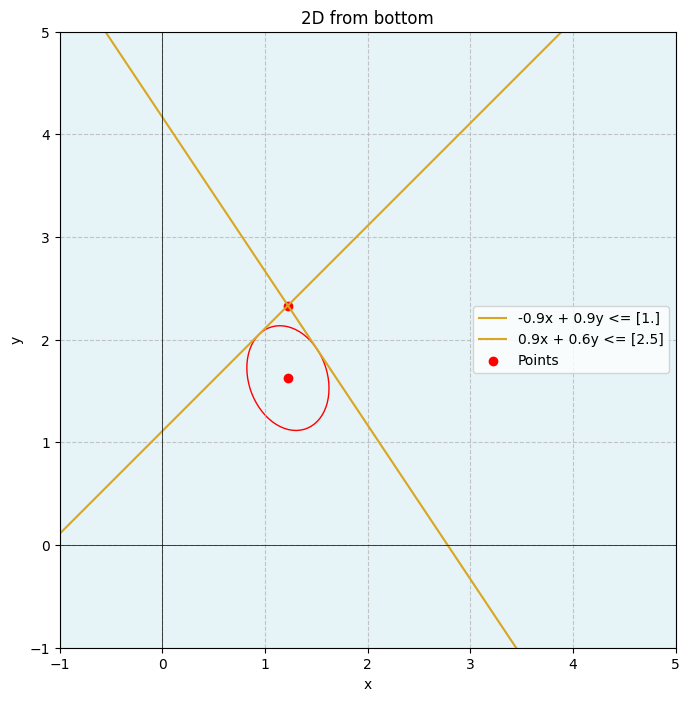

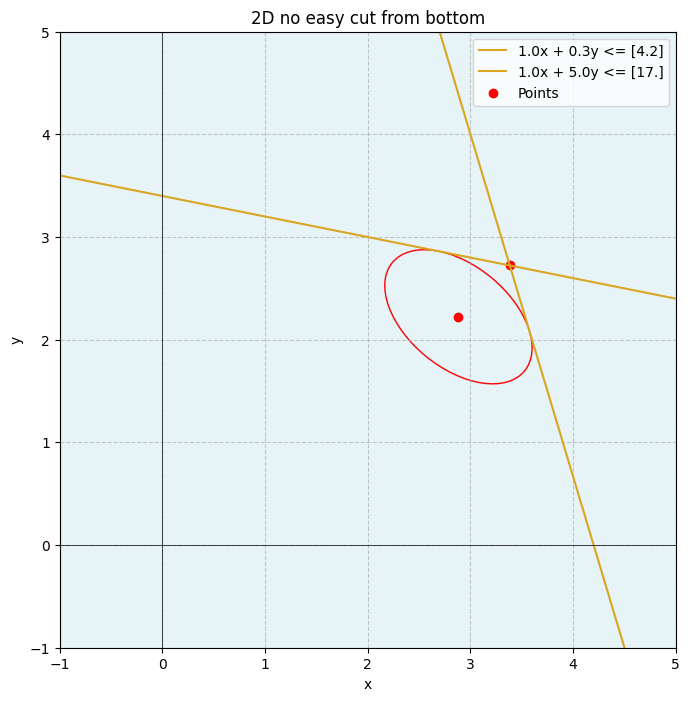

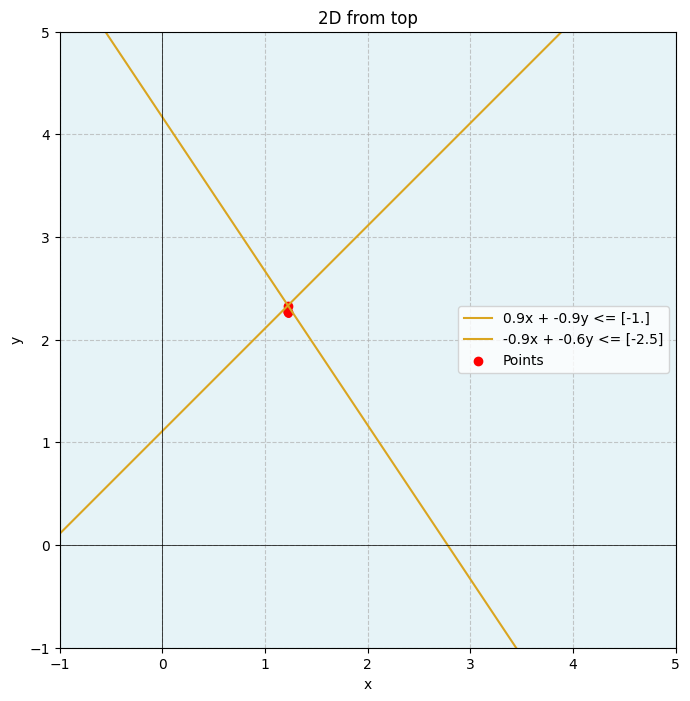

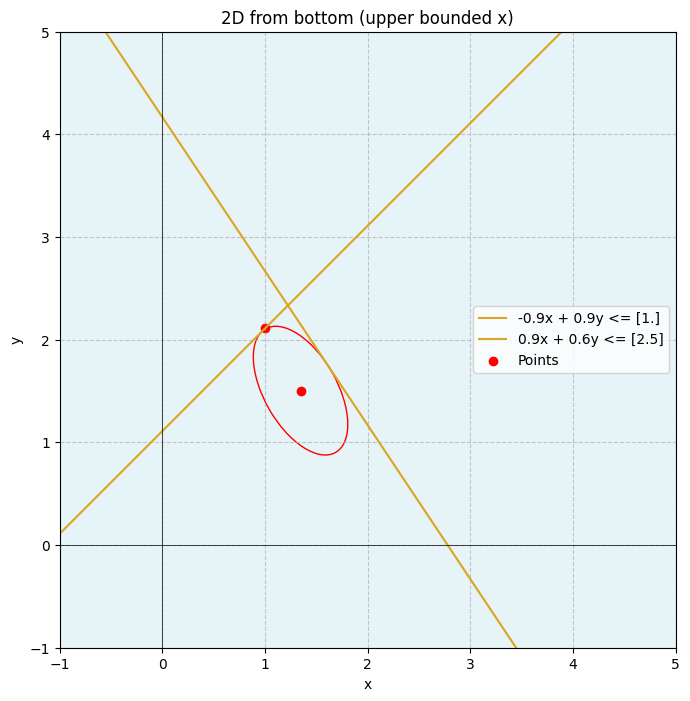

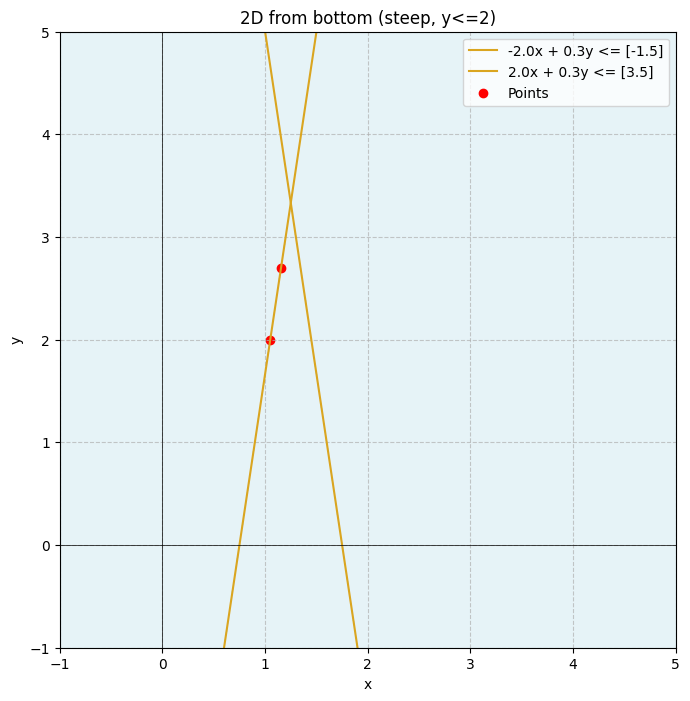

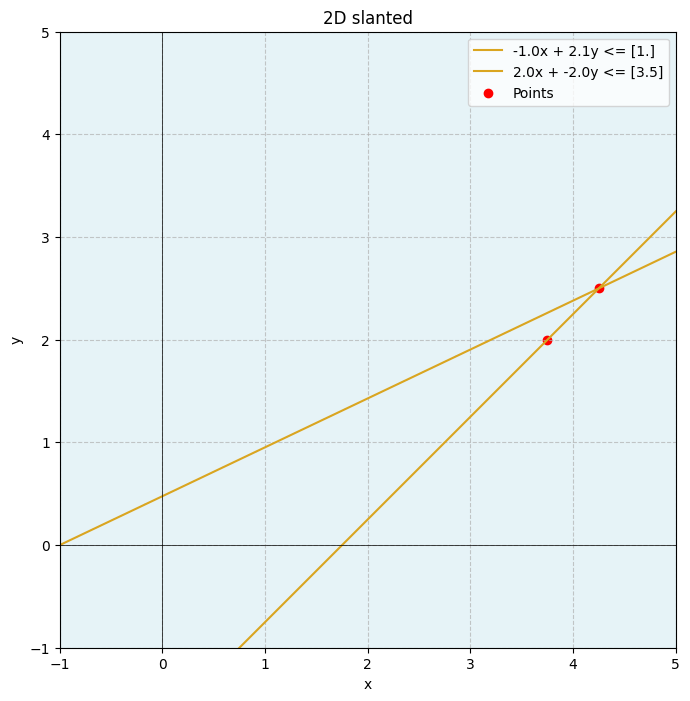

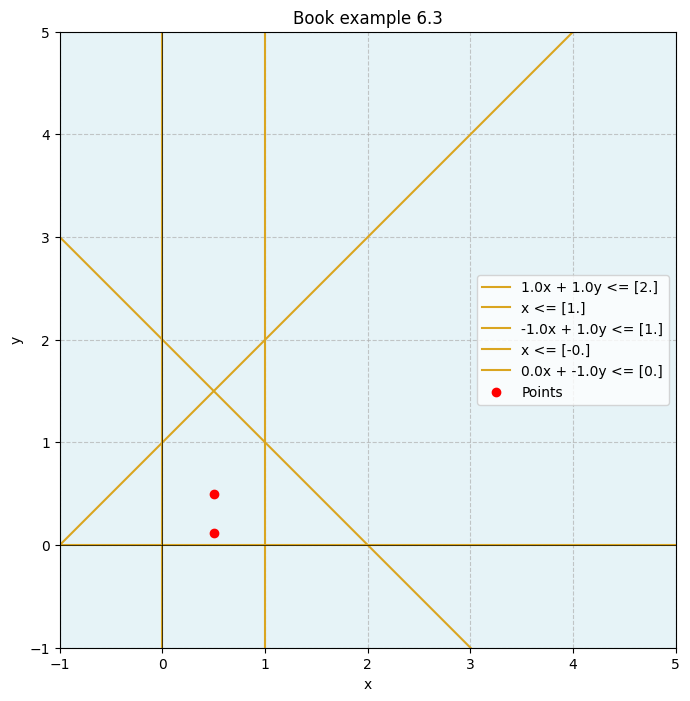

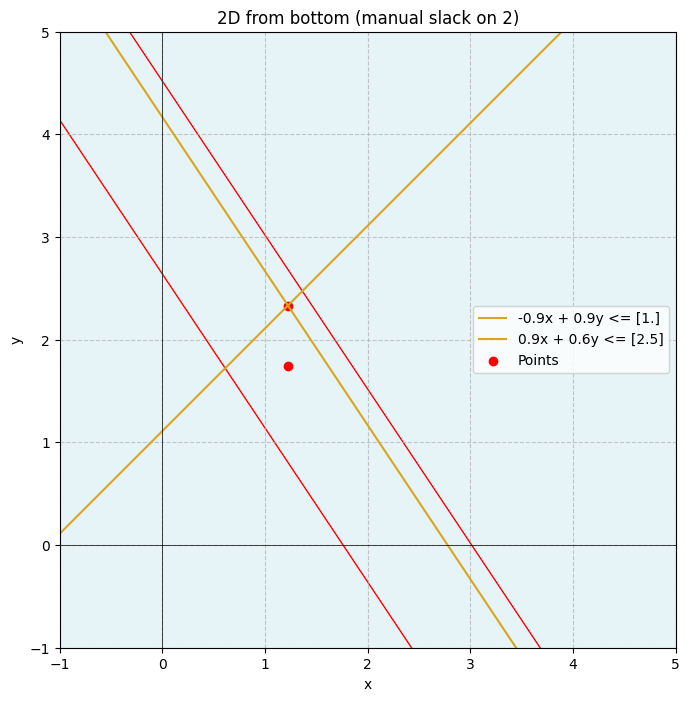

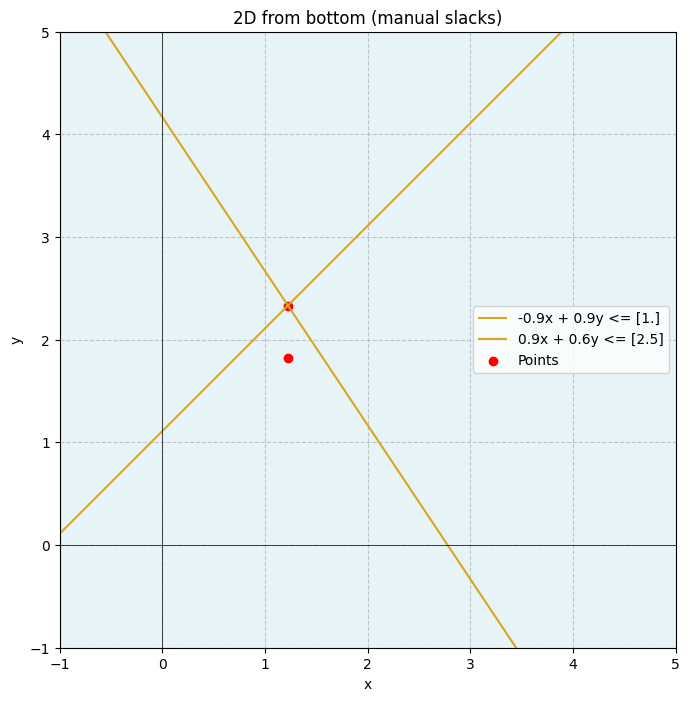

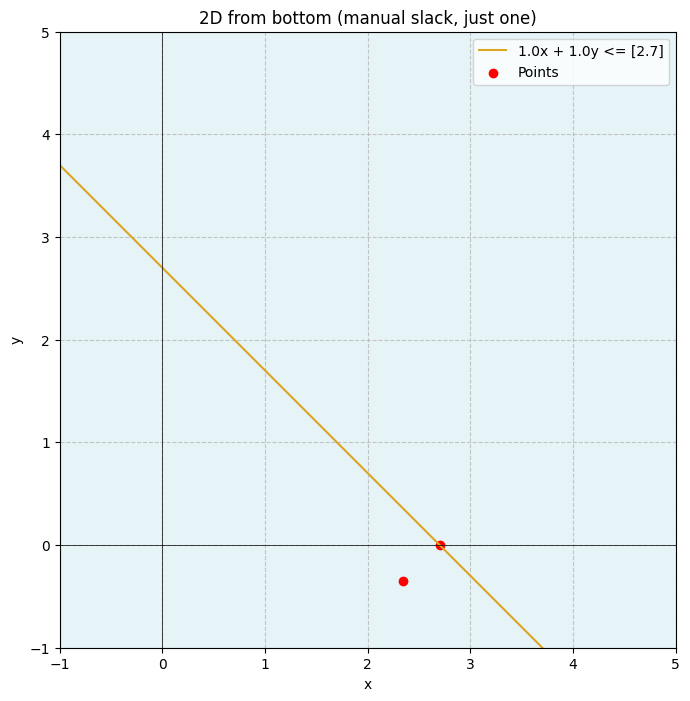

In [ ]:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

instances = el.get_instances(env)
for instance in list(instances.values()):
    model = instance.as_gurobi_model()
    print("Running:", model.ModelName)
    gu.standardize_gt_to_lt(model)
    int_vars, int_var_idx = gu.relax_int_or_bin_to_continuous(model)
    model.optimize()
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    x, y = make_primal_dual_values(model)
    A = model.getA()
    b = np.array(model.getAttr("RHS")).reshape(-1, 1)
    x2, its = du.reverse_interior_point_gpt(A, b, x, y, target_distance=np.sqrt(int_vars.size) * 0.4)
    print("   Optimum:", x, "Retreat to:", x2, "Iters:", its)
    fig = pu.plot_constraints_lte(model.ModelName, A, b, points=[x[:2], x2[:2]])
    du.plot_ellipse(A, b, x2, fig=fig)

    # could assert x2 is feasible


